# 06 Forbes–Rigobon Adjusted Correlations

This notebook turns the raw stress-period correlation increases of notebook 03 into a
sharper question: *did the dependence relationship itself change in stress, or is the
correlation rise just a mechanical consequence of inflated stress-period variance?*
Forbes & Rigobon (2002) show that a measured correlation rises automatically when the
common factor becomes more volatile, even if the underlying linear relationship is
unchanged. The adjustment deflates each stress correlation by the variance shock it
carries:

$$\tilde{\rho}^{\,\mathrm{stress}}_{ij}=\frac{\rho^{\,\mathrm{stress}}_{ij}}{\sqrt{1+\delta_{ij}\,\bigl(1-(\rho^{\,\mathrm{stress}}_{ij})^2\bigr)}}.$$

We report two variants:

- **`market_spy` (main):** every SPY pair is deflated by SPY's own stress-vs-calm
  variance shock — the single common market factor, the variant most faithful to
  Forbes–Rigobon.
- **`pair_max` (conservative robustness):** every pair is deflated by the larger of the
  two assets' variance shocks, the most demanding correction.

**The variance shock is clipped at zero**, $\delta=\max(\sigma^2_{\mathrm{stress}}/\sigma^2_{\mathrm{calm}}-1,\,0)$.
Classical Forbes–Rigobon is one-sided: the high-volatility regime can only carry
*excess* variance, so the adjustment can only ever shrink a correlation. A negative shock
(an asset that is *less* volatile in stress) would instead inflate the correlation, which
is outside the framework; Section 5 flags any such asset as a diagnostic.

Each pair is then placed in a four-class fragility taxonomy on a fixed 0.10 breakdown
threshold: **robust breakdown** (the rise survives adjustment), **volatility-bias-sensitive**
(the rise is mechanical), **resilient – decreased** (diversifies better in stress), and
**mostly resilient** (a small rise either way).

Upstream dependencies: the `correlation_pairs` table from
`scripts/07_build_regime_correlations.py` and the labeled returns table
`etf_returns_monthly_markov_labeled`.

## 1. Setup

In [1]:
# =====================================================================
# Notebook 06 -- Forbes-Rigobon Adjusted Correlations: setup
#
# Deflates each stress correlation by its Forbes-Rigobon variance shock (the SPY
# market shock, and a conservative pair-max variant), classifies every pair into
# the fragility taxonomy, and writes all report figures (PNG) and tables (CSV) to
# outputs/06_adjusted_correlation/. Uses the repository-anchored settings paths.
# =====================================================================
from __future__ import annotations

from pathlib import Path
import sys

import duckdb
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import numpy as np
import pandas as pd
from IPython.display import display
from plotnine import *


def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "src").is_dir() and (path / "data").is_dir():
            return path
    raise RuntimeError("Could not find project root containing src/ and data/.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import settings
from analysis.forbes_rigobon import (
    ADJUSTMENT_UNAVAILABLE,
    MOSTLY_RESILIENT,
    RESILIENT_DECREASED,
    ROBUST_BREAKDOWN,
    VOLATILITY_BIAS_SENSITIVE,
    build_all_forbes_rigobon_outputs,
    write_outputs,
)
from analysis.notebook_outputs import format_forbes_rigobon_table
from analysis.regime_correlations import common_complete_case_dates
from features.regime_assignment import ETF_TABLE

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)

## 2. Settings

In [2]:
REBUILD_FR_TABLES = True
WRITE_TO_DATABASE = False
EXPORT_OUTPUTS = True

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "06_adjusted_correlation"
SCHEMA_DIR = PROJECT_ROOT / "sql" / "schema"
PLOT_DPI = 150

FR_UNIVERSES = (
    ("panel_a_cross_asset", settings.PANEL_A),
    ("panel_b_international_equity", settings.PANEL_B),
    ("etf_assets", settings.ETF_ASSETS),
)

UNIVERSE_LABELS = {
    "panel_a_cross_asset": "Panel A: cross-asset",
    "panel_b_international_equity": "Panel B: international equity",
    "etf_assets": "Combined ETF assets",
}
UNIVERSE_ORDER = [UNIVERSE_LABELS[name] for name, _ in FR_UNIVERSES]

METHOD_LABELS = {
    "market_spy": "SPY market shock (main)",
    "pair_max": "Pair-max (conservative)",
}
PAIR_GROUP_ORDER = ["Non-SPY pair", "SPY pair"]

# Fragility classes ordered most-fragile -> most-resilient, with a fixed palette.
CLASS_ORDER = [
    ROBUST_BREAKDOWN,
    VOLATILITY_BIAS_SENSITIVE,
    MOSTLY_RESILIENT,
    RESILIENT_DECREASED,
    ADJUSTMENT_UNAVAILABLE,
]
CLASS_COLORS = {
    ROBUST_BREAKDOWN: "#D62728",
    VOLATILITY_BIAS_SENSITIVE: "#F58518",
    MOSTLY_RESILIENT: "#4C78A8",
    RESILIENT_DECREASED: "#54A24B",
    ADJUSTMENT_UNAVAILABLE: "#9E9E9E",
}
BREAKDOWN_THRESHOLD = 0.10

CANONICAL_PAIR_COLS = [
    "universe", "correlation_method", "fr_method", "source_asset",
    "asset_i", "asset_j", "corr_calm", "corr_stress", "delta_corr",
    "fr_delta_asset_i", "fr_delta_asset_j", "fr_delta_spy", "fr_delta_used",
    "corr_stress_adjusted", "delta_corr_adjusted", "interpretation",
]
PAIR_MAX_VIEW_COLS = [
    "universe", "pair", "pair_group", "corr_calm", "corr_stress", "delta_corr",
    "source_asset", "fr_delta_used", "corr_stress_adjusted", "delta_corr_adjusted",
    "interpretation",
]
FR_SCHEMA_FILES = [
    "09_forbes_rigobon_variance_ratios.sql",
    "09_forbes_rigobon_adjusted_pairs.sql",
    "09_forbes_rigobon_adjusted_summary.sql",
]

if EXPORT_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

figure_exports = []


def save_plot(plot, filename, *, width=8.5, height=4.4):
    if EXPORT_OUTPUTS:
        path = OUTPUT_DIR / filename
        plot.save(path, width=width, height=height, dpi=PLOT_DPI, verbose=False)
        figure_exports.append({"figure": filename, "path": str(path)})


print(f"Database: {settings.DB_PATH}")
print(f"Outputs : {OUTPUT_DIR}")

Database: C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\data\lsr.duckdb
Outputs : C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\outputs\06_adjusted_correlation


## 3. Load Data

In [3]:
settings.require_data_dir()
if not settings.DB_PATH.exists():
    raise FileNotFoundError(
        f"Database not found: {settings.DB_PATH}. Run the pipeline scripts first."
    )

con = duckdb.connect(str(settings.DB_PATH))
available_tables = set(con.execute("SHOW TABLES").fetchdf()["name"])
for required in ("correlation_pairs", ETF_TABLE):
    if required not in available_tables:
        raise RuntimeError(
            f"Missing required table: {required}. Run scripts 06 and 07 first."
        )

raw_labeled = con.execute(f"SELECT * FROM {ETF_TABLE} ORDER BY date").fetchdf()
raw_labeled["date"] = pd.to_datetime(raw_labeled["date"])

# Same balanced window as notebooks 03 and 05: the dates where every combined-universe
# asset is observed (HYG's April-2007 inception binds it). Computing the variance shocks
# on this window puts them on the identical trading days as the raw correlations they
# adjust.
COMMON_DATES = common_complete_case_dates(raw_labeled, list(settings.ETF_ASSETS))
print(
    f"common window: {COMMON_DATES.min().date()} -> {COMMON_DATES.max().date()} "
    f"({len(COMMON_DATES):,} trading days)"
)

common window: 2007-04-12 -> 2025-12-30 (4,711 trading days)


## 4. Compute Forbes–Rigobon Outputs

In [4]:
variance_ratios, adjusted_pairs, summary = build_all_forbes_rigobon_outputs(
    con, raw_labeled, list(FR_UNIVERSES), restrict_dates=COMMON_DATES
)

# The signed raw shock (before the clip) is recoverable from the variance ratio; keep it
# as a diagnostic column without touching the canonical clipped fr_delta.
variance_ratios["fr_delta_raw"] = variance_ratios["variance_ratio"] - 1.0

# Convenience labels for plotting / display.
adjusted_pairs["universe_label"] = pd.Categorical(
    adjusted_pairs["universe"].map(UNIVERSE_LABELS), categories=UNIVERSE_ORDER, ordered=True
)
adjusted_pairs["method_label"] = adjusted_pairs["fr_method"].map(METHOD_LABELS)
adjusted_pairs["pair"] = adjusted_pairs["asset_i"] + "-" + adjusted_pairs["asset_j"]
adjusted_pairs["is_spy_pair"] = (
    adjusted_pairs["asset_i"].eq("SPY") | adjusted_pairs["asset_j"].eq("SPY")
)
adjusted_pairs["pair_group"] = pd.Categorical(
    np.where(adjusted_pairs["is_spy_pair"], "SPY pair", "Non-SPY pair"),
    categories=PAIR_GROUP_ORDER,
    ordered=True,
)

sample_overview = (
    adjusted_pairs.groupby(["universe", "fr_method"]).size().rename("pairs").reset_index()
    .pivot(index="universe", columns="fr_method", values="pairs").reset_index()
)
sample_overview.insert(1, "label", sample_overview["universe"].map(UNIVERSE_LABELS))
print("Adjusted pair rows per universe and method:")
display(sample_overview)

Adjusted pair rows per universe and method:

fr_method,universe,label,market_spy,pair_max
0,etf_assets,Combined ETF assets,13,91
1,panel_a_cross_asset,Panel A: cross-asset,8,36
2,panel_b_international_equity,Panel B: international equity,5,15


## 5. Diagnostic: Negative Variance Shocks

`fr_delta` is the canonical clipped shock; `fr_delta_raw = variance_ratio - 1` is the
signed shock before clipping. A negative raw shock means the asset was *less* volatile in
stress than in calm — the case classical Forbes–Rigobon does not cover and that the clip
neutralizes. The main `market_spy` method is immune because SPY's shock is strongly
positive; only `pair_max` could be affected, and only for pairs where *both* assets have a
negative raw shock.

In [5]:
delta_view = variance_ratios[
    ["universe", "asset", "calm_variance", "stress_variance", "variance_ratio",
     "fr_delta_raw", "fr_delta"]
].copy()

negative_shocks = (
    delta_view[delta_view["fr_delta_raw"] < 0].sort_values("fr_delta_raw").reset_index(drop=True)
)
print(f"Assets with falling stress variance (raw shock < 0): {len(negative_shocks)}")
display(negative_shocks.round(6))

# pair_max pairs the clip protected from inflation: both assets' raw shock < 0, so the
# pre-clip max shock would have been negative and inflated the correlation.
raw_delta_by_key = variance_ratios.set_index(["universe", "asset"])["fr_delta_raw"]
pair_max = adjusted_pairs[adjusted_pairs["fr_method"] == "pair_max"].copy()
pair_max["raw_i"] = [raw_delta_by_key.get((u, a), np.nan)
                     for u, a in zip(pair_max["universe"], pair_max["asset_i"])]
pair_max["raw_j"] = [raw_delta_by_key.get((u, a), np.nan)
                     for u, a in zip(pair_max["universe"], pair_max["asset_j"])]
protected = pair_max[(pair_max["raw_i"] < 0) & (pair_max["raw_j"] < 0)]
print(
    f"pair_max pairs the clip protected from inflation (both shocks < 0): "
    f"{len(protected)} of {len(pair_max)}"
)
spy_raw = variance_ratios.loc[variance_ratios["asset"] == "SPY", "fr_delta_raw"]
print(f"SPY raw shock across universes: {spy_raw.min():.3f} .. {spy_raw.max():.3f} (clip never binds)")

Assets with falling stress variance (raw shock < 0): 0


,universe,asset,calm_variance,stress_variance,variance_ratio,fr_delta_raw,fr_delta


pair_max pairs the clip protected from inflation (both shocks < 0): 0 of 142
SPY raw shock across universes: 2.967 .. 2.967 (clip never binds)


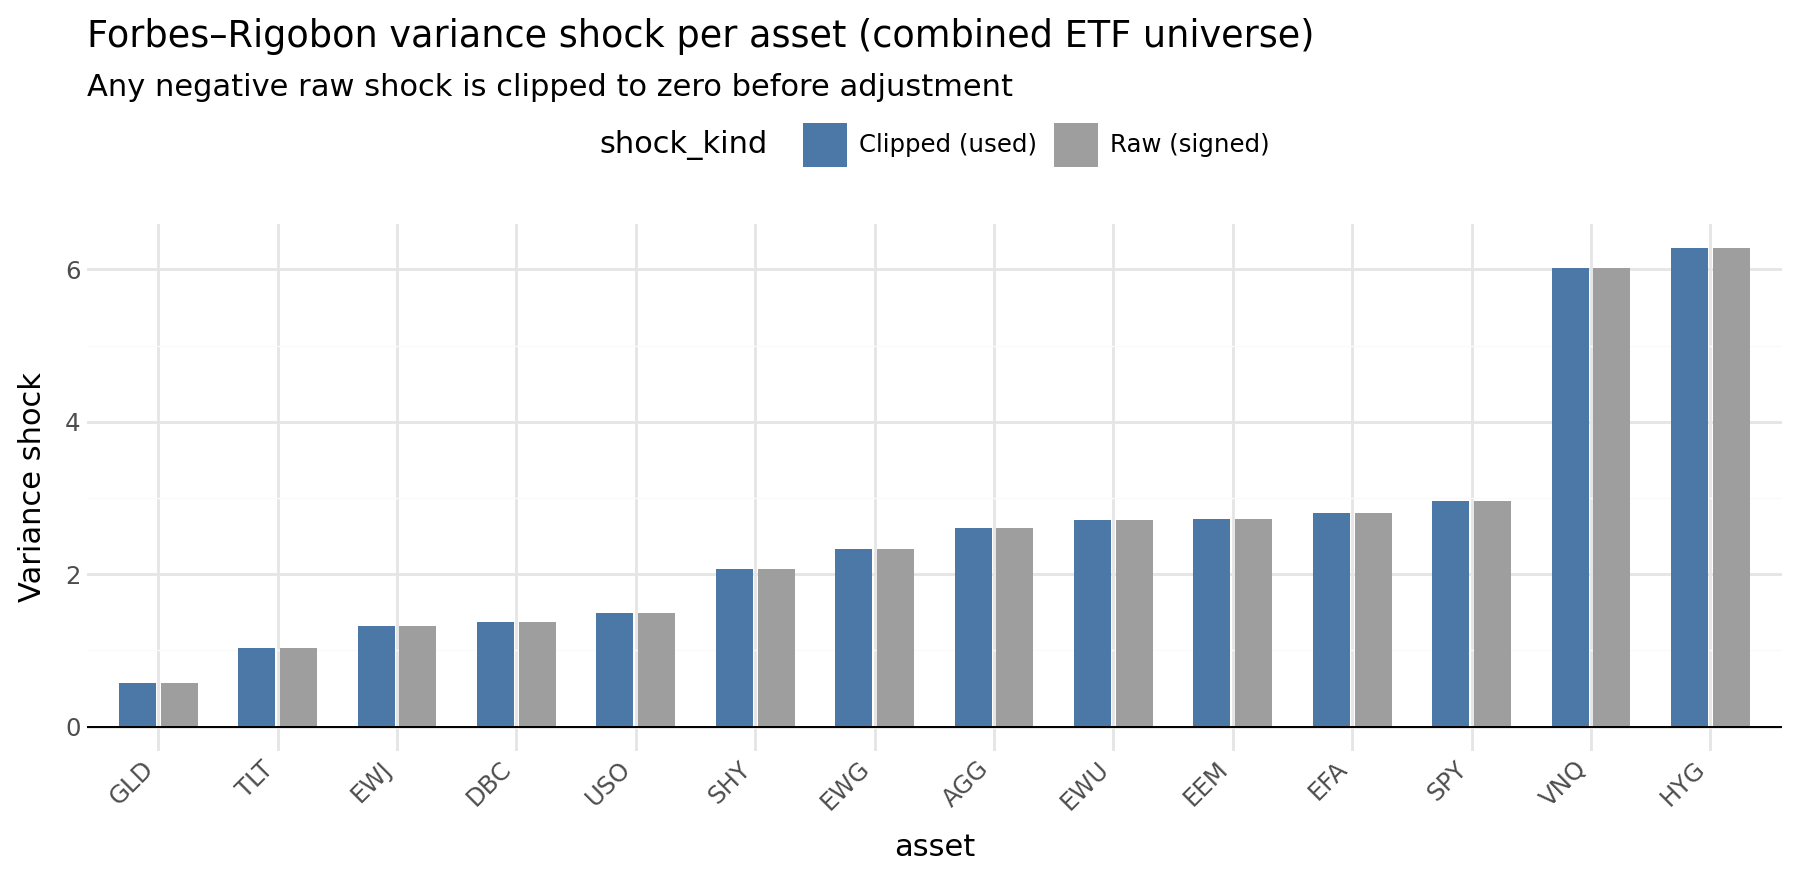

In [6]:
shock_data = delta_view[delta_view["universe"] == "etf_assets"].copy()
asset_order = shock_data.sort_values("fr_delta_raw")["asset"].tolist()
shock_long = shock_data.melt(
    id_vars="asset", value_vars=["fr_delta_raw", "fr_delta"],
    var_name="shock_kind", value_name="shock",
)
shock_long["shock_kind"] = shock_long["shock_kind"].map(
    {"fr_delta_raw": "Raw (signed)", "fr_delta": "Clipped (used)"}
)
shock_long["asset"] = pd.Categorical(shock_long["asset"], categories=asset_order, ordered=True)

shock_plot = (
    ggplot(shock_long, aes(x="asset", y="shock", fill="shock_kind"))
    + geom_col(position=position_dodge(width=0.7), width=0.62)
    + geom_hline(yintercept=0, color="black", size=0.4)
    + scale_fill_manual(values={"Raw (signed)": "#9E9E9E", "Clipped (used)": "#4C78A8"})
    + labs(
        title="Forbes–Rigobon variance shock per asset (combined ETF universe)",
        subtitle="Any negative raw shock is clipped to zero before adjustment",
        x=None, y="Variance shock", fill=None,
    )
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=45, ha="right"), legend_position="top",
            figure_size=(9, 4.4))
)
save_plot(shock_plot, "forbes_rigobon_variance_shock_by_asset.png", width=9, height=4.4)
display(shock_plot)

## 6. Main Tables

The variance shocks per universe (SPY is the source asset of the main method), the
`market_spy` adjusted SPY pairs sorted by raw breakdown, the dedicated all-pair
`pair_max` adjustment table, and the fragility-class classification counts per
universe and method.

In [7]:
variance_table = (
    variance_ratios.sort_values(["universe", "fr_delta"], ascending=[True, False])
    .reset_index(drop=True)
)
display(variance_table.round(6))

,universe,asset,calm_variance,stress_variance,variance_ratio,fr_delta,fr_delta_raw
0,etf_assets,HYG,0.000012,0.000087,7.286507,6.286507,6.286507
1,etf_assets,VNQ,0.000092,0.000645,7.017587,6.017587,6.017587
2,etf_assets,SPY,0.000064,0.000255,3.966781,2.966781,2.966781
3,etf_assets,EFA,0.000080,0.000306,3.801431,2.801431,2.801431
4,etf_assets,EEM,0.000134,0.000499,3.729338,2.729338,2.729338
5,etf_assets,EWU,0.000093,0.000344,3.712039,2.712039,2.712039
6,etf_assets,AGG,0.000005,0.000019,3.609724,2.609724,2.609724
7,etf_assets,EWG,0.000124,0.000412,3.334550,2.334550,2.334550
8,etf_assets,SHY,0.000000,0.000001,3.075234,2.075234,2.075234
9,etf_assets,USO,0.000319,0.000797,2.495052,1.495052,1.495052


In [8]:
market_spy_pairs = adjusted_pairs[adjusted_pairs["fr_method"] == "market_spy"].copy()
spy_view_cols = [
    "asset_i", "asset_j", "corr_calm", "corr_stress", "delta_corr",
    "fr_delta_used", "corr_stress_adjusted", "delta_corr_adjusted", "interpretation",
]
for universe, _ in FR_UNIVERSES:
    sub = market_spy_pairs[market_spy_pairs["universe"] == universe].sort_values(
        "delta_corr", ascending=False
    )
    print(f"market_spy adjusted SPY pairs: {UNIVERSE_LABELS[universe]}")
    display(format_forbes_rigobon_table(sub[spy_view_cols]))

pair_max_all_pairs = (
    adjusted_pairs[adjusted_pairs["fr_method"] == "pair_max"]
    .sort_values(["universe", "pair_group", "delta_corr"], ascending=[True, True, False])
    .reset_index(drop=True)
)
pair_max_non_spy_pairs = pair_max_all_pairs[~pair_max_all_pairs["is_spy_pair"]].copy()

print(f"pair_max all-pair FR adjustment rows: {len(pair_max_all_pairs)}")
display(format_forbes_rigobon_table(pair_max_all_pairs[PAIR_MAX_VIEW_COLS]))

print(f"pair_max non-SPY robustness rows: {len(pair_max_non_spy_pairs)}")
display(format_forbes_rigobon_table(pair_max_non_spy_pairs[PAIR_MAX_VIEW_COLS]))

market_spy adjusted SPY pairs: Panel A: cross-asset


,asset_i,asset_j,corr_calm,corr_stress,delta_corr,fr_delta_used,corr_stress_adjusted,delta_corr_adjusted,interpretation
7,SPY,VNQ,0.5850,0.7948,0.2098,2.9668,0.5494,-0.0355,Volatility-bias-sensitive increase
1,SPY,DBC,0.2939,0.4679,0.1740,2.9668,0.2569,-0.0370,Volatility-bias-sensitive increase
6,SPY,USO,0.2467,0.4187,0.1720,2.9668,0.2255,-0.0212,Volatility-bias-sensitive increase
0,SPY,AGG,-0.0694,0.0081,0.0776,2.9668,0.0041,0.0735,Mostly resilient / small adjusted increase
3,SPY,HYG,0.6654,0.6916,0.0262,2.9668,0.4333,-0.2321,Mostly resilient / small adjusted increase
2,SPY,GLD,0.0607,0.0462,-0.0145,2.9668,0.0232,-0.0375,Resilient: correlation decreased in stress
4,SPY,SHY,-0.1869,-0.2586,-0.0717,2.9668,-0.1332,0.0537,Resilient: correlation decreased in stress
5,SPY,TLT,-0.2208,-0.3581,-0.1374,2.9668,-0.1891,0.0317,Resilient: correlation decreased in stress


market_spy adjusted SPY pairs: Panel B: international equity


,asset_i,asset_j,corr_calm,corr_stress,delta_corr,fr_delta_used,corr_stress_adjusted,delta_corr_adjusted,interpretation
47,SPY,EWJ,0.6566,0.8164,0.1598,2.9668,0.5788,-0.0778,Volatility-bias-sensitive increase
48,SPY,EWU,0.7176,0.8675,0.1499,2.9668,0.6588,-0.0588,Volatility-bias-sensitive increase
46,SPY,EWG,0.7303,0.8550,0.1247,2.9668,0.6376,-0.0927,Volatility-bias-sensitive increase
44,SPY,EEM,0.7312,0.8542,0.1230,2.9668,0.6363,-0.0949,Volatility-bias-sensitive increase
45,SPY,EFA,0.8102,0.9090,0.0988,2.9668,0.7384,-0.0718,Mostly resilient / small adjusted increase


market_spy adjusted SPY pairs: Combined ETF assets


,asset_i,asset_j,corr_calm,corr_stress,delta_corr,fr_delta_used,corr_stress_adjusted,delta_corr_adjusted,interpretation
76,SPY,VNQ,0.5850,0.7948,0.2098,2.9668,0.5494,-0.0355,Volatility-bias-sensitive increase
65,SPY,DBC,0.2939,0.4679,0.1740,2.9668,0.2569,-0.0370,Volatility-bias-sensitive increase
75,SPY,USO,0.2467,0.4187,0.1720,2.9668,0.2255,-0.0212,Volatility-bias-sensitive increase
69,SPY,EWJ,0.6566,0.8164,0.1598,2.9668,0.5788,-0.0778,Volatility-bias-sensitive increase
70,SPY,EWU,0.7176,0.8675,0.1499,2.9668,0.6588,-0.0588,Volatility-bias-sensitive increase
68,SPY,EWG,0.7303,0.8550,0.1247,2.9668,0.6376,-0.0927,Volatility-bias-sensitive increase
66,SPY,EEM,0.7312,0.8542,0.1230,2.9668,0.6363,-0.0949,Volatility-bias-sensitive increase
67,SPY,EFA,0.8102,0.9090,0.0988,2.9668,0.7384,-0.0718,Mostly resilient / small adjusted increase
64,SPY,AGG,-0.0694,0.0081,0.0776,2.9668,0.0041,0.0735,Mostly resilient / small adjusted increase
72,SPY,HYG,0.6654,0.6916,0.0262,2.9668,0.4333,-0.2321,Mostly resilient / small adjusted increase


pair_max all-pair FR adjustment rows: 142


,universe,pair,pair_group,corr_calm,corr_stress,delta_corr,source_asset,fr_delta_used,corr_stress_adjusted,delta_corr_adjusted,interpretation
0,etf_assets,VNQ-EWU,Non-SPY pair,0.4791,0.7136,0.2345,VNQ,6.0176,0.3589,-0.1202,Volatility-bias-sensitive increase
1,etf_assets,DBC-VNQ,Non-SPY pair,0.1081,0.3408,0.2327,VNQ,6.0176,0.1356,0.0275,Volatility-bias-sensitive increase
2,etf_assets,USO-VNQ,Non-SPY pair,0.0671,0.2984,0.2313,VNQ,6.0176,0.1172,0.0501,Volatility-bias-sensitive increase
3,etf_assets,VNQ-EEM,Non-SPY pair,0.4870,0.7150,0.2280,VNQ,6.0176,0.3602,-0.1269,Volatility-bias-sensitive increase
4,etf_assets,VNQ-EWG,Non-SPY pair,0.4636,0.6857,0.2220,VNQ,6.0176,0.3350,-0.1286,Volatility-bias-sensitive increase
5,etf_assets,VNQ-EWJ,Non-SPY pair,0.4204,0.6417,0.2213,VNQ,6.0176,0.3012,-0.1192,Volatility-bias-sensitive increase
6,etf_assets,VNQ-EFA,Non-SPY pair,0.5265,0.7365,0.2101,VNQ,6.0176,0.3802,-0.1463,Volatility-bias-sensitive increase
7,etf_assets,EEM-EWJ,Non-SPY pair,0.5958,0.8016,0.2058,EEM,2.7293,0.5704,-0.0254,Volatility-bias-sensitive increase
8,etf_assets,EWU-EWJ,Non-SPY pair,0.6046,0.7995,0.1949,EWU,2.7120,0.5684,-0.0362,Volatility-bias-sensitive increase
9,etf_assets,DBC-EWJ,Non-SPY pair,0.2274,0.4195,0.1921,DBC,1.3678,0.2876,0.0602,Volatility-bias-sensitive increase


pair_max non-SPY robustness rows: 116


,universe,pair,pair_group,corr_calm,corr_stress,delta_corr,source_asset,fr_delta_used,corr_stress_adjusted,delta_corr_adjusted,interpretation
0,etf_assets,VNQ-EWU,Non-SPY pair,0.4791,0.7136,0.2345,VNQ,6.0176,0.3589,-0.1202,Volatility-bias-sensitive increase
1,etf_assets,DBC-VNQ,Non-SPY pair,0.1081,0.3408,0.2327,VNQ,6.0176,0.1356,0.0275,Volatility-bias-sensitive increase
2,etf_assets,USO-VNQ,Non-SPY pair,0.0671,0.2984,0.2313,VNQ,6.0176,0.1172,0.0501,Volatility-bias-sensitive increase
3,etf_assets,VNQ-EEM,Non-SPY pair,0.4870,0.7150,0.2280,VNQ,6.0176,0.3602,-0.1269,Volatility-bias-sensitive increase
4,etf_assets,VNQ-EWG,Non-SPY pair,0.4636,0.6857,0.2220,VNQ,6.0176,0.3350,-0.1286,Volatility-bias-sensitive increase
5,etf_assets,VNQ-EWJ,Non-SPY pair,0.4204,0.6417,0.2213,VNQ,6.0176,0.3012,-0.1192,Volatility-bias-sensitive increase
6,etf_assets,VNQ-EFA,Non-SPY pair,0.5265,0.7365,0.2101,VNQ,6.0176,0.3802,-0.1463,Volatility-bias-sensitive increase
7,etf_assets,EEM-EWJ,Non-SPY pair,0.5958,0.8016,0.2058,EEM,2.7293,0.5704,-0.0254,Volatility-bias-sensitive increase
8,etf_assets,EWU-EWJ,Non-SPY pair,0.6046,0.7995,0.1949,EWU,2.7120,0.5684,-0.0362,Volatility-bias-sensitive increase
9,etf_assets,DBC-EWJ,Non-SPY pair,0.2274,0.4195,0.1921,DBC,1.3678,0.2876,0.0602,Volatility-bias-sensitive increase


In [9]:
summary_display = summary.copy()
summary_display.insert(1, "label", summary_display["universe"].map(UNIVERSE_LABELS))
summary_display["fr_method"] = summary_display["fr_method"].map(METHOD_LABELS)
display(format_forbes_rigobon_table(summary_display).round(4))

,universe,label,fr_method,adjusted_rows,available_rows,unavailable_rows,avg_delta_corr,median_delta_corr,avg_delta_corr_adjusted,median_delta_corr_adjusted,robust_breakdown_count,volatility_bias_sensitive_count,resilient_decreased_count,mostly_resilient_count,adjustment_unavailable_count
0,etf_assets,Combined ETF assets,SPY market shock (main),13,13,0,0.0840,0.1230,-0.0462,-0.0375,0,7,3,3,0
1,etf_assets,Combined ETF assets,Pair-max (conservative),91,91,0,0.0291,0.0499,-0.0801,-0.0677,0,31,38,22,0
2,panel_a_cross_asset,Panel A: cross-asset,SPY market shock (main),8,8,0,0.0545,0.0519,-0.0256,-0.0283,0,3,3,2,0
3,panel_a_cross_asset,Panel A: cross-asset,Pair-max (conservative),36,36,0,-0.0246,-0.0243,-0.0968,-0.0845,0,5,22,9,0
4,panel_b_international_equity,Panel B: international equity,SPY market shock (main),5,5,0,0.1312,0.1247,-0.0792,-0.0778,0,4,0,1,0
5,panel_b_international_equity,Panel B: international equity,Pair-max (conservative),15,15,0,0.1245,0.1247,-0.0683,-0.0718,0,11,0,4,0


## 7. Headline: Raw vs Adjusted Breakdown

Each point is one SPY pair under the main `market_spy` method. The horizontal axis is the
raw stress-minus-calm correlation change; the vertical axis is the change after the
variance adjustment. Points below the dashed 45° line lost correlation to the volatility
correction. The dotted lines mark the 0.10 breakdown threshold: only points in the
upper-right block past both dotted lines are *robust breakdowns* that survive adjustment.

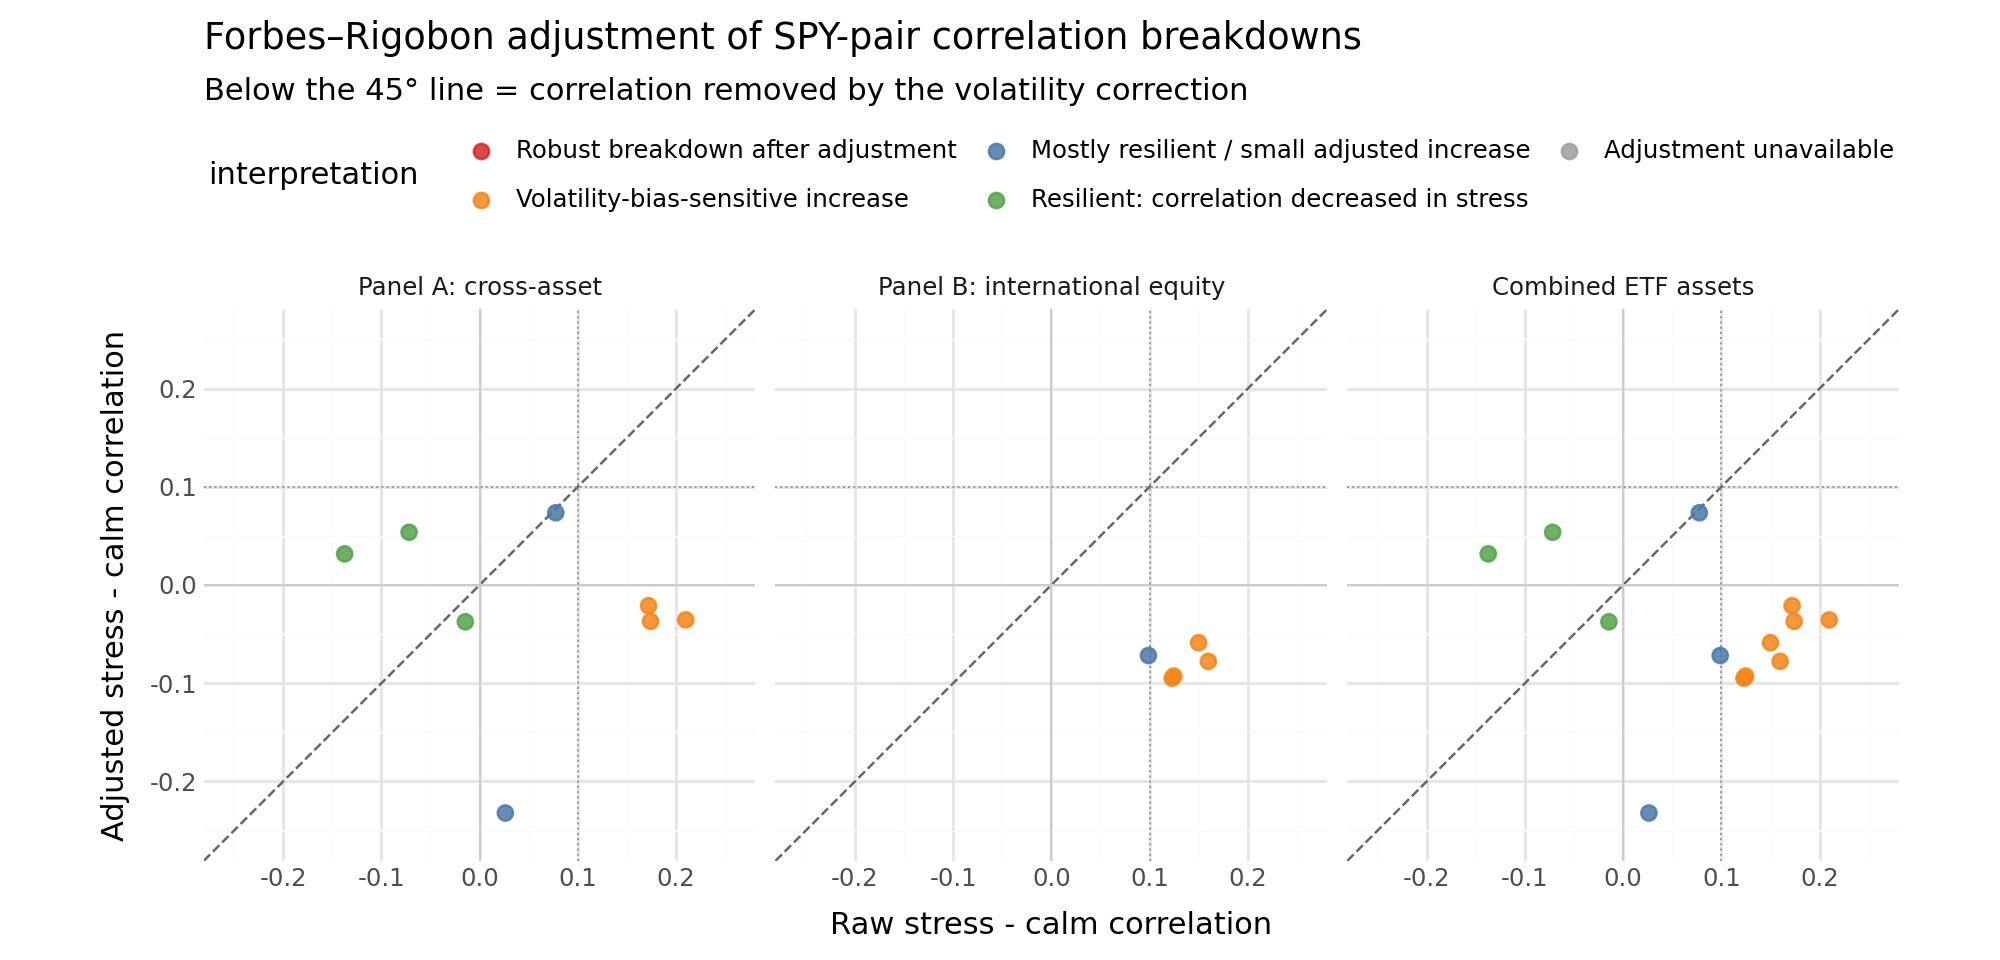

In [10]:
headline = market_spy_pairs.dropna(subset=["delta_corr", "delta_corr_adjusted"]).copy()
headline["interpretation"] = pd.Categorical(
    headline["interpretation"], categories=CLASS_ORDER, ordered=True
)
lim = float(np.nanmax(np.abs(np.concatenate([
    headline["delta_corr"].to_numpy(), headline["delta_corr_adjusted"].to_numpy()
]))) * 1.1)

headline_plot = (
    ggplot(headline, aes(x="delta_corr", y="delta_corr_adjusted", color="interpretation"))
    + geom_abline(slope=1, intercept=0, linetype="dashed", color="#666666", size=0.5)
    + geom_hline(yintercept=0, color="#cccccc", size=0.4)
    + geom_vline(xintercept=0, color="#cccccc", size=0.4)
    + geom_hline(yintercept=BREAKDOWN_THRESHOLD, linetype="dotted", color="#999999", size=0.4)
    + geom_vline(xintercept=BREAKDOWN_THRESHOLD, linetype="dotted", color="#999999", size=0.4)
    + geom_point(size=2.6, alpha=0.85)
    + scale_color_manual(values=CLASS_COLORS, drop=False)
    + coord_fixed(xlim=(-lim, lim), ylim=(-lim, lim))
    + facet_wrap("universe_label")
    + labs(
        title="Forbes–Rigobon adjustment of SPY-pair correlation breakdowns",
        subtitle="Below the 45° line = correlation removed by the volatility correction",
        x="Raw stress - calm correlation", y="Adjusted stress - calm correlation", color=None,
    )
    + theme_minimal()
    + theme(legend_position="top", figure_size=(10, 4.8))
    + guides(color=guide_legend(nrow=2))
)
save_plot(headline_plot, "forbes_rigobon_raw_vs_adjusted_market_spy.png", width=10, height=4.8)
display(headline_plot)

## 8. Pair-Level Survival

For the combined ETF universe, each SPY pair is drawn as a segment from its raw breakdown
(circle) to its adjusted breakdown (diamond). The dotted line is the 0.10 threshold:
pairs whose diamond stays to the right of it remain robust breakdowns, while pairs whose
diamond falls back across it were volatility-bias-sensitive.

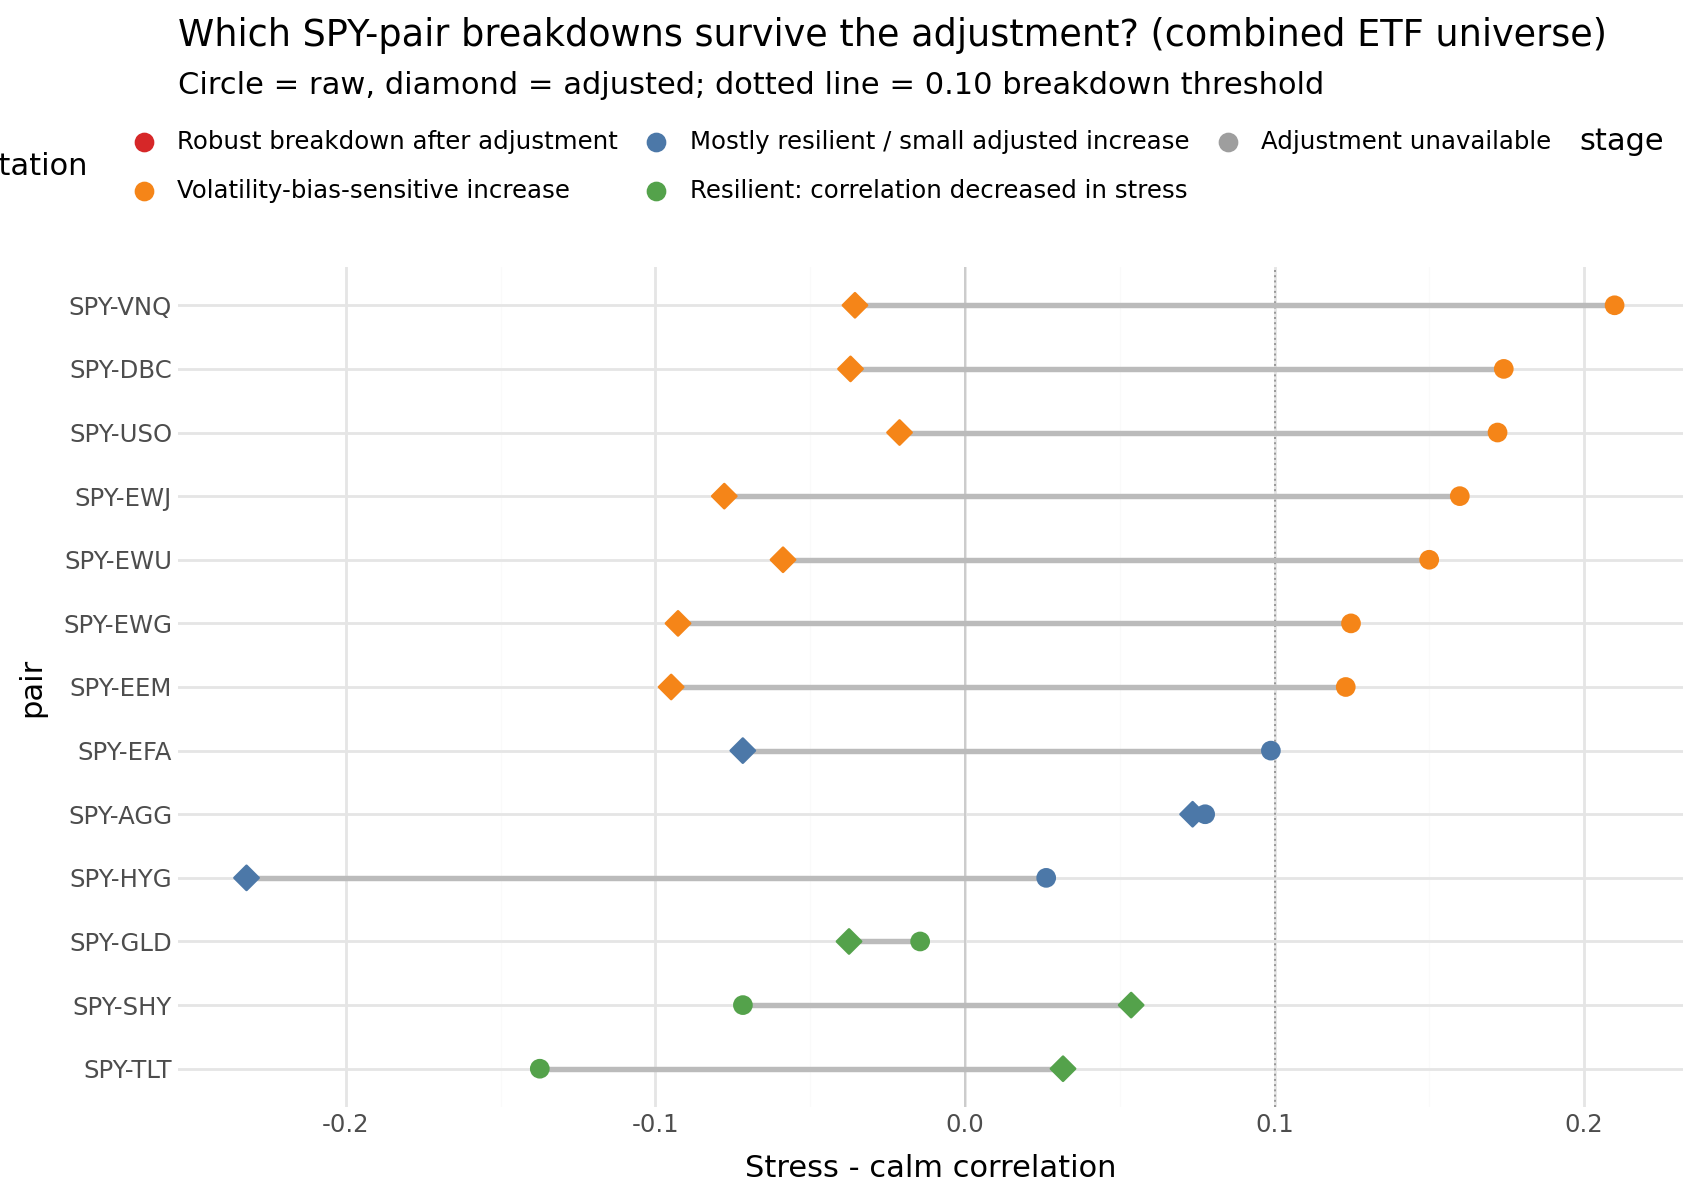

In [11]:
survival = market_spy_pairs[market_spy_pairs["universe"] == "etf_assets"].copy()
survival = survival.dropna(subset=["delta_corr", "delta_corr_adjusted"]).sort_values("delta_corr")
pair_order = survival["pair"].tolist()
survival["pair"] = pd.Categorical(survival["pair"], categories=pair_order, ordered=True)

survival_long = survival.melt(
    id_vars=["pair", "interpretation"], value_vars=["delta_corr", "delta_corr_adjusted"],
    var_name="stage", value_name="value",
)
survival_long["stage"] = survival_long["stage"].map(
    {"delta_corr": "Raw", "delta_corr_adjusted": "Adjusted"}
)
survival_long["pair"] = pd.Categorical(survival_long["pair"], categories=pair_order, ordered=True)
survival_long["interpretation"] = pd.Categorical(
    survival_long["interpretation"], categories=CLASS_ORDER, ordered=True
)

survival_plot = (
    ggplot()
    + geom_vline(xintercept=0, color="#cccccc", size=0.4)
    + geom_vline(xintercept=BREAKDOWN_THRESHOLD, linetype="dotted", color="#999999", size=0.4)
    + geom_segment(survival, aes(x="delta_corr", xend="delta_corr_adjusted", y="pair", yend="pair"),
                   color="#bbbbbb", size=1.1)
    + geom_point(survival_long, aes(x="value", y="pair", color="interpretation", shape="stage"),
                 size=3.0)
    + scale_color_manual(values=CLASS_COLORS, drop=False)
    + scale_shape_manual(values={"Raw": "o", "Adjusted": "D"})
    + labs(
        title="Which SPY-pair breakdowns survive the adjustment? (combined ETF universe)",
        subtitle="Circle = raw, diamond = adjusted; dotted line = 0.10 breakdown threshold",
        x="Stress - calm correlation", y=None, color=None, shape=None,
    )
    + theme_minimal()
    + theme(legend_position="top", figure_size=(8.5, 6.0))
    + guides(color=guide_legend(nrow=2))
)
save_plot(survival_plot, "forbes_rigobon_breakdown_survival.png", width=8.5, height=6.0)
display(survival_plot)

## 9. Fragility-Class Composition

How the pairs of each universe split across the four fragility classes, shown for both
adjustment methods. `market_spy` covers SPY pairs only; `pair_max` covers every pair.

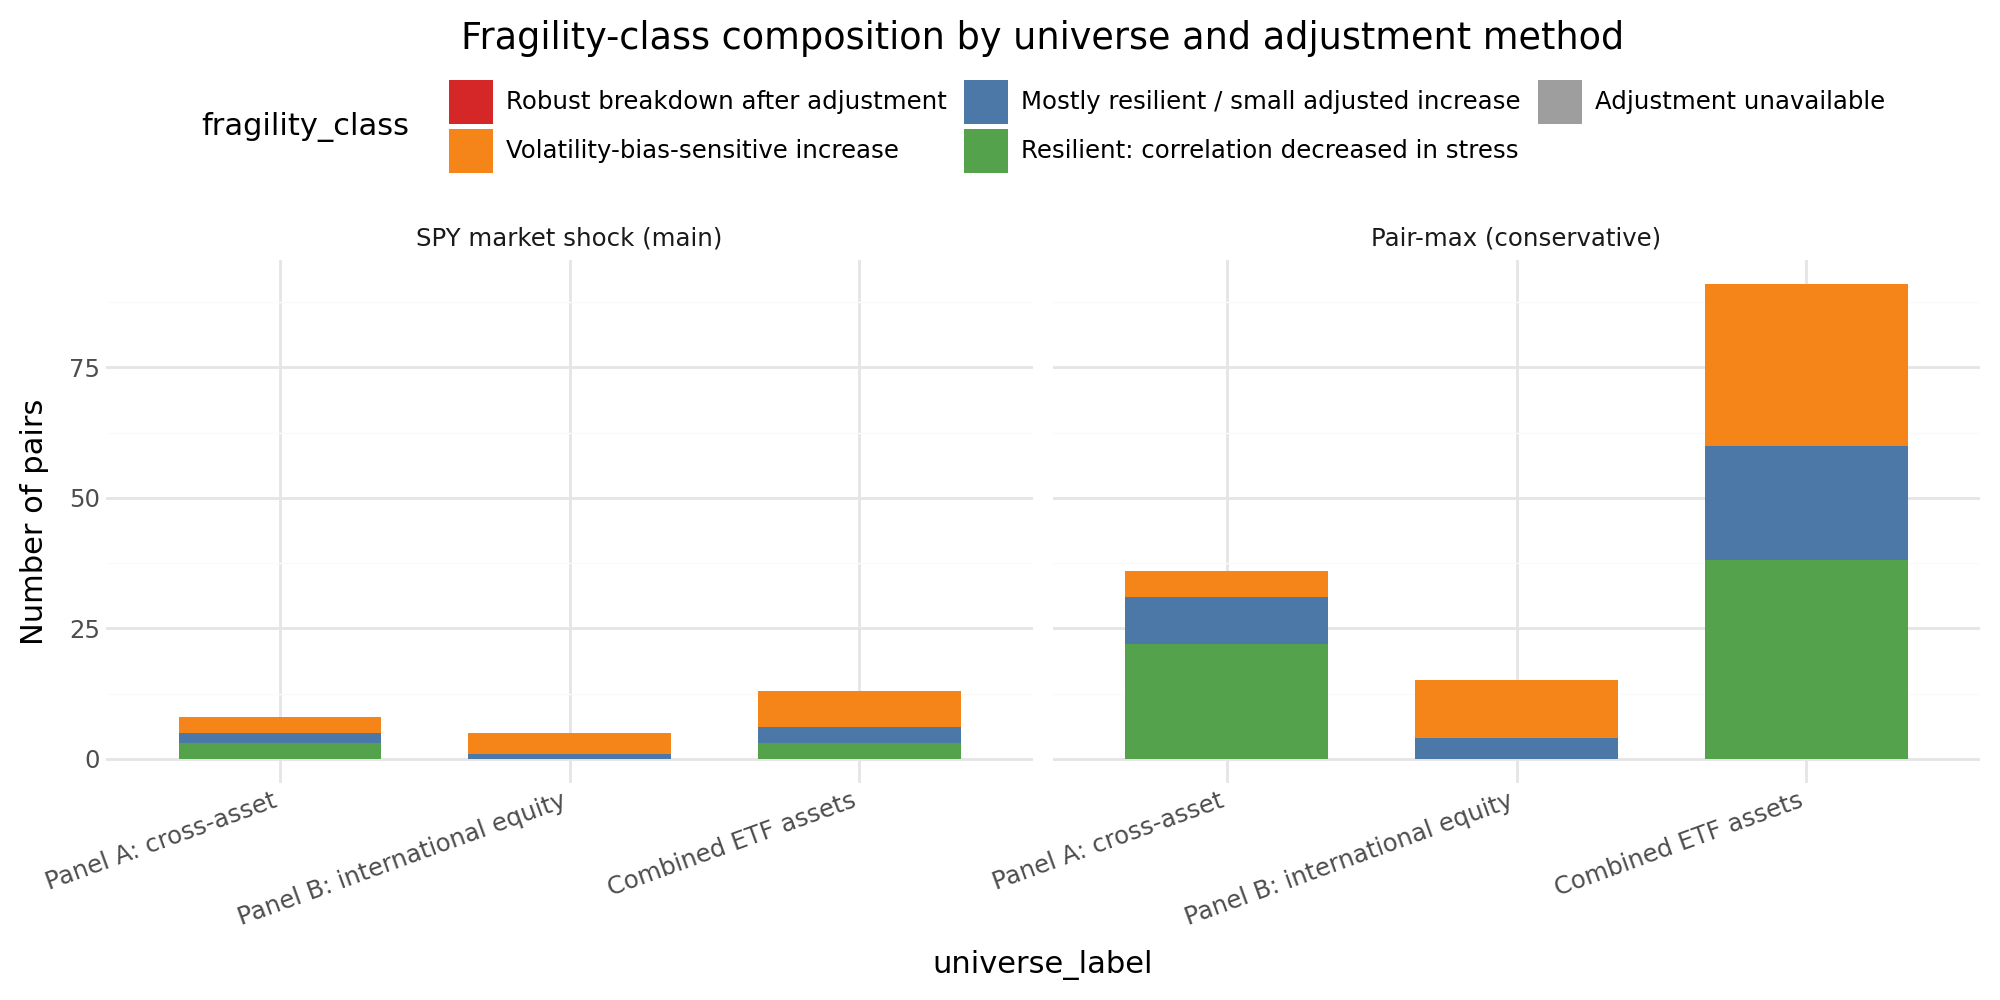

In [12]:
count_cols = {
    "robust_breakdown_count": ROBUST_BREAKDOWN,
    "volatility_bias_sensitive_count": VOLATILITY_BIAS_SENSITIVE,
    "mostly_resilient_count": MOSTLY_RESILIENT,
    "resilient_decreased_count": RESILIENT_DECREASED,
    "adjustment_unavailable_count": ADJUSTMENT_UNAVAILABLE,
}
comp = summary.melt(
    id_vars=["universe", "fr_method"], value_vars=list(count_cols),
    var_name="class_col", value_name="n_pairs",
)
comp["fragility_class"] = pd.Categorical(
    comp["class_col"].map(count_cols), categories=CLASS_ORDER, ordered=True
)
comp["universe_label"] = pd.Categorical(
    comp["universe"].map(UNIVERSE_LABELS), categories=UNIVERSE_ORDER, ordered=True
)
comp["method_label"] = pd.Categorical(
    comp["fr_method"].map(METHOD_LABELS),
    categories=[METHOD_LABELS["market_spy"], METHOD_LABELS["pair_max"]], ordered=True,
)

comp_plot = (
    ggplot(comp, aes(x="universe_label", y="n_pairs", fill="fragility_class"))
    + geom_col(width=0.7)
    + scale_fill_manual(values=CLASS_COLORS, drop=False)
    + facet_wrap("method_label")
    + labs(
        title="Fragility-class composition by universe and adjustment method",
        x=None, y="Number of pairs", fill=None,
    )
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=20, ha="right"), legend_position="top",
            figure_size=(10, 5.0))
    + guides(fill=guide_legend(nrow=2))
)
save_plot(comp_plot, "forbes_rigobon_class_composition.png", width=10, height=5.0)
display(comp_plot)

## 10. Robustness: non-SPY pair_max pairs

The conservative `pair_max` adjustment is most informative away from SPY pairs, because
those observations are not just the same SPY-linked set as the headline method. This plot
therefore keeps only pairs where neither asset is `SPY` and compares their raw breakdown
with their `pair_max` adjusted breakdown.

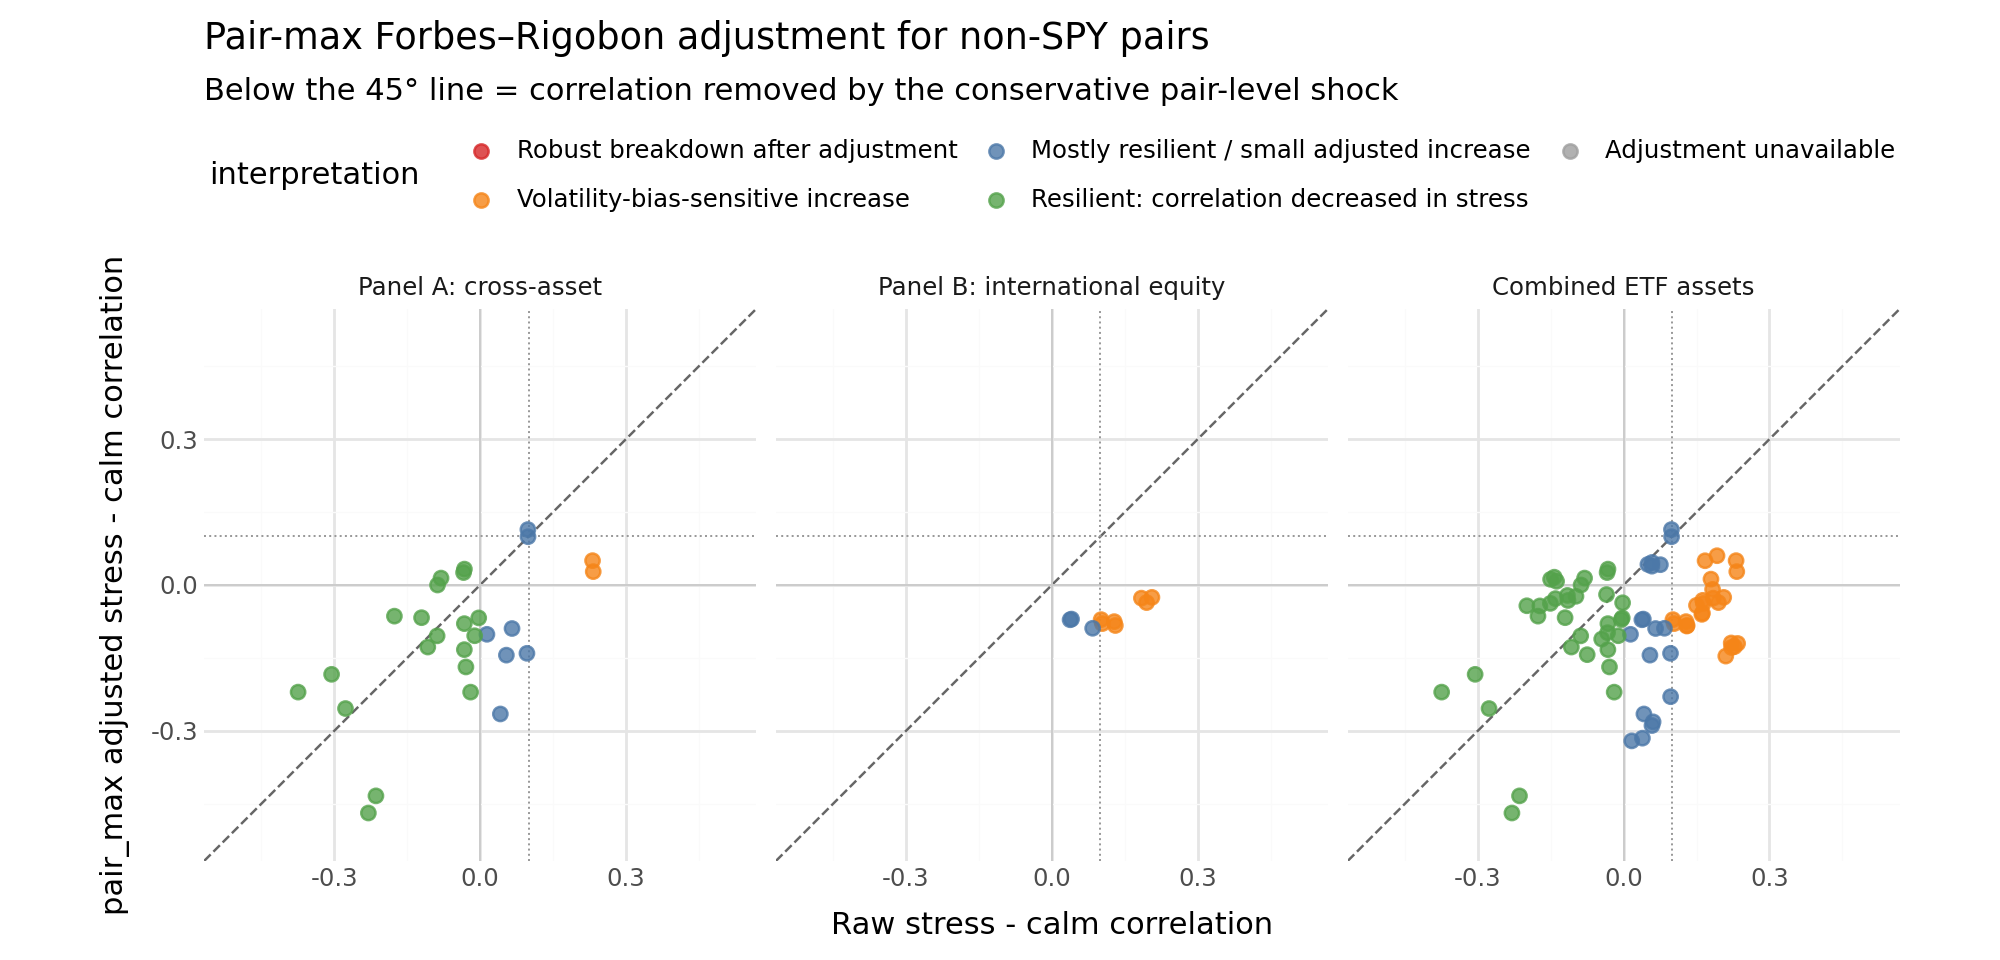

In [13]:
non_spy_robustness = pair_max_non_spy_pairs.dropna(
    subset=["delta_corr", "delta_corr_adjusted"]
).copy()
non_spy_robustness["universe_label"] = pd.Categorical(
    non_spy_robustness["universe"].map(UNIVERSE_LABELS),
    categories=UNIVERSE_ORDER,
    ordered=True,
)
non_spy_robustness["interpretation"] = pd.Categorical(
    non_spy_robustness["interpretation"], categories=CLASS_ORDER, ordered=True
)
rlim = float(np.nanmax(np.abs(np.concatenate([
    non_spy_robustness["delta_corr"].to_numpy(),
    non_spy_robustness["delta_corr_adjusted"].to_numpy(),
]))) * 1.1)

non_spy_plot = (
    ggplot(non_spy_robustness, aes(x="delta_corr", y="delta_corr_adjusted", color="interpretation"))
    + geom_abline(slope=1, intercept=0, linetype="dashed", color="#666666", size=0.5)
    + geom_hline(yintercept=0, color="#cccccc", size=0.4)
    + geom_vline(xintercept=0, color="#cccccc", size=0.4)
    + geom_hline(yintercept=BREAKDOWN_THRESHOLD, linetype="dotted", color="#999999", size=0.4)
    + geom_vline(xintercept=BREAKDOWN_THRESHOLD, linetype="dotted", color="#999999", size=0.4)
    + geom_point(size=2.4, alpha=0.8)
    + scale_color_manual(values=CLASS_COLORS, drop=False)
    + coord_fixed(xlim=(-rlim, rlim), ylim=(-rlim, rlim))
    + facet_wrap("universe_label")
    + labs(
        title="Pair-max Forbes–Rigobon adjustment for non-SPY pairs",
        subtitle="Below the 45° line = correlation removed by the conservative pair-level shock",
        x="Raw stress - calm correlation", y="pair_max adjusted stress - calm correlation",
        color=None,
    )
    + theme_minimal()
    + theme(legend_position="top", figure_size=(10, 4.8))
    + guides(color=guide_legend(nrow=2))
)
save_plot(
    non_spy_plot,
    "forbes_rigobon_pair_max_non_spy_raw_vs_adjusted.png",
    width=10,
    height=4.8,
)
display(non_spy_plot)

## 11. Invariant Checks

Guards that the adjustment behaves as classical Forbes–Rigobon requires before anything is
written to the database.

In [14]:
assert adjusted_pairs["corr_stress_adjusted"].dropna().between(-1, 1).all(),     "Adjusted stress correlations must stay in [-1, 1]."
assert (variance_ratios["fr_delta"].dropna() >= 0).all(), "Clipped fr_delta must be >= 0."

ms_check = adjusted_pairs[adjusted_pairs["fr_method"] == "market_spy"].dropna(
    subset=["corr_stress_adjusted", "delta_corr_adjusted"]
)
# market_spy uses SPY's shock (>= 0), so it can only shrink |corr| toward zero.
assert (ms_check["corr_stress_adjusted"].abs() <= ms_check["corr_stress"].abs() + 1e-9).all(),     "market_spy must not increase |stress correlation|."
# Sign is preserved; the deflation never flips a correlation across zero.
assert (np.sign(ms_check["corr_stress_adjusted"]) == np.sign(ms_check["corr_stress"])).all(),     "market_spy must preserve the sign of the stress correlation."
# For positively-correlated pairs that means the breakdown can only fall (for negatively
# correlated pairs |corr| still shrinks toward zero, raising delta, which is expected).
ms_pos = ms_check[ms_check["corr_stress"] > 0]
assert (ms_pos["delta_corr_adjusted"] <= ms_pos["delta_corr"] + 1e-9).all(),     "market_spy must not raise the breakdown of a positively-correlated pair."

pair_max_check = adjusted_pairs[adjusted_pairs["fr_method"] == "pair_max"]
assert len(pair_max_all_pairs) == len(pair_max_check),     "All-pair pair_max table must contain every pair_max row."
assert not pair_max_non_spy_pairs.empty, "Non-SPY pair_max robustness table must not be empty."
assert (~pair_max_non_spy_pairs["is_spy_pair"]).all(),     "Non-SPY robustness table must exclude every SPY pair."

recount = adjusted_pairs.groupby(["universe", "fr_method"]).size().rename("n").reset_index()
merged = summary.merge(recount, on=["universe", "fr_method"])
assert (merged["adjusted_rows"] == merged["n"]).all(), "Summary counts must match pair rows."
print("All Forbes-Rigobon invariants hold.")

All Forbes-Rigobon invariants hold.


## 12. Persist Canonical Outputs

Rebuild the three Forbes–Rigobon tables from their explicit SQL schemas and insert the
results. Set `WRITE_TO_DATABASE = False` above for in-memory-only runs.

In [15]:
if WRITE_TO_DATABASE:
    if REBUILD_FR_TABLES:
        for schema_file in FR_SCHEMA_FILES:
            con.execute((SCHEMA_DIR / schema_file).read_text(encoding="utf-8"))

    variance_db = variance_ratios.drop(columns=["fr_delta_raw"])
    pairs_db = adjusted_pairs[CANONICAL_PAIR_COLS].copy()
    write_outputs(con, variance_db, pairs_db, summary)
    con.commit()

    persisted = {
        table: con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        for table in (
            "forbes_rigobon_variance_ratios",
            "forbes_rigobon_adjusted_pairs",
            "forbes_rigobon_adjusted_summary",
        )
    }
    print(persisted)
else:
    print("Database write skipped.")

Database write skipped.


## 13. Export Figures and Tables

In [16]:
if EXPORT_OUTPUTS:
    table_exports = {
        "forbes_rigobon_variance_ratios.csv": variance_ratios,
        "forbes_rigobon_adjusted_pairs.csv": adjusted_pairs[CANONICAL_PAIR_COLS],
        "forbes_rigobon_pair_max_all_pairs.csv": pair_max_all_pairs[PAIR_MAX_VIEW_COLS],
        "forbes_rigobon_pair_max_non_spy_pairs.csv": pair_max_non_spy_pairs[PAIR_MAX_VIEW_COLS],
        "forbes_rigobon_adjusted_summary.csv": summary,
        "forbes_rigobon_negative_shocks.csv": negative_shocks,
    }
    exported = []
    for filename, frame in table_exports.items():
        path = OUTPUT_DIR / filename
        frame.to_csv(path, index=False)
        exported.append({"table": filename, "rows": len(frame), "path": str(path)})
    display(pd.DataFrame(exported))
    display(pd.DataFrame(figure_exports))
else:
    print("Export skipped.")

,table,rows,path
0,forbes_rigobon_variance_ratios.csv,29,C:\Users\salio\OneDrive\Desktop\University\TUM...
1,forbes_rigobon_adjusted_pairs.csv,168,C:\Users\salio\OneDrive\Desktop\University\TUM...
2,forbes_rigobon_pair_max_all_pairs.csv,142,C:\Users\salio\OneDrive\Desktop\University\TUM...
3,forbes_rigobon_pair_max_non_spy_pairs.csv,116,C:\Users\salio\OneDrive\Desktop\University\TUM...
4,forbes_rigobon_adjusted_summary.csv,6,C:\Users\salio\OneDrive\Desktop\University\TUM...
5,forbes_rigobon_negative_shocks.csv,0,C:\Users\salio\OneDrive\Desktop\University\TUM...


,figure,path
0,forbes_rigobon_variance_shock_by_asset.png,C:\Users\salio\OneDrive\Desktop\University\TUM...
1,forbes_rigobon_raw_vs_adjusted_market_spy.png,C:\Users\salio\OneDrive\Desktop\University\TUM...
2,forbes_rigobon_breakdown_survival.png,C:\Users\salio\OneDrive\Desktop\University\TUM...
3,forbes_rigobon_class_composition.png,C:\Users\salio\OneDrive\Desktop\University\TUM...
4,forbes_rigobon_pair_max_non_spy_raw_vs_adjuste...,C:\Users\salio\OneDrive\Desktop\University\TUM...


## 14. Close

In [17]:
con.close()